# Wavefield · Elastic TTI in 3-D

`ElasticTTISG3D` is the three-dimensional elastic TTI equation on an
**axis-aligned staggered grid** (the same Virieux layout as `Elastic3D`; only
the constitutive update changes, to the full 21-entry Bond-rotated stiffness).
Unlike the 2-D `ElasticTTI`, which uses a rotated staggered grid, this one has
a compiled `impl='c'` backend with full / boundary-saving / checkpoint
gradients for all eight parameters.

In 3-D the symmetry axis needs **both** angles to be pinned down, so the
azimuth φ stops being decorative: a tilted axis with φ ≠ 0 sends the qP
wavefront out of the x–z plane, which is something no 2-D run can show.

| Case | θ (dip) | φ (azimuth) |
|---|---|---|
| `VTI 0/0` | 0° | 0° — vertical axis, wavefront symmetric about z |
| `TTI 40/0` | 40° | 0° — axis dips in the x–z plane |
| `TTI 40/45` | 40° | 45° — axis dips out of plane |


## 1. Parameters

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from sweep.equations import ElasticTTISG3D
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

shape = (288, 288, 288)        # 2.88 km cube at 10 m spacing  (nz, ny, nx)
dh    = 10.0
dt    = 1.2e-3
nt    = 360                    # 0.43 s
abcn  = 18                     # PML width
spatial_order = 4
freq, delay = 8.0, 0.12
# Last snapshot must land BEFORE the fastest front reaches the PML: the
# horizontal qP velocity is vp0*sqrt(1+2*eps) = 3036 m/s, so it covers the
# 1440 m half-width in 0.47 s.
snapshot_times = (120, 240, 350)

vp_val, vs_val, rho_val = 2400.0, 1200.0, 2200.0
epsilon_val, delta_val, gamma_val = 0.30, 0.05, 0.15

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# Discretisation is set by the SLOWEST wave, not the fastest: check the shear
# points-per-wavelength before anything else, and the CFL after it.
ppw = vs_val / (2.5 * freq) / dh
cfl = vp_val * dt / dh
print(f'S-wave ppw at fmax = {ppw:.2f}  (>= 5 for 4th order)')
print(f'CFL = {cfl:.3f}')
assert ppw >= 5.0 and cfl <= 0.45

device: cuda
S-wave ppw at fmax = 6.00  (>= 5 for 4th order)
CFL = 0.288


## 2. Uniform anisotropic model

`ElasticTTISG3D` takes the same **eight** fields as the 2-D staggered-grid
variant — `vp0, vs0, rho, ε, δ, γ, θ, φ` — and turns them into `rho` plus the
21 independent Voigt stiffnesses through a 3-D Bond rotation. The eight
physical parameters stay differentiable: the CUDA backend returns gradients
with respect to the 21 stiffnesses and autograd chains them back through the
rotation.

In [2]:
def build_models(theta_deg, phi_deg):
    full = lambda v: torch.full(shape, float(v), dtype=torch.float32, device=device)
    return [
        full(vp_val), full(vs_val), full(rho_val),
        full(epsilon_val), full(delta_val), full(gamma_val),
        full(np.deg2rad(theta_deg)),
        full(np.deg2rad(phi_deg)),
    ]

## 3. Solver and source

A single explosion (`sxx + syy + szz`) at the centre of the cube. Snapshots
come out of the eager backend, which exposes the whole field stack; the
compiled backend is the one to use for gradients.

In [3]:
eq = ElasticTTISG3D(spatial_order=spatial_order, device=device)
solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, dev=device, nt=nt,
                   abcn=abcn, source_type=['sxx', 'syy', 'szz'],
                   receiver_type=['vx', 'vy', 'vz'],
                   impl='eager', use_ckpt=False)

cz, cy, cx = (s // 2 for s in shape)
sources   = np.array([[[cx, cy, cz]]], dtype=np.int64)   # (batch, nsrc, 3) as (x, y, z)
receivers = np.array([[[cx, cy, cz]]], dtype=np.int64)   # dummy single receiver

t = np.arange(nt, dtype=np.float32) * dt - delay
wavelet = (1e3 * ricker(t, f=freq)).astype(np.float32)
print('wavelet:', wavelet.shape, ' source:', sources.shape)

wavelet: (360,)  source: (1, 1, 3)


### Aside · free surface is refused here

Every anisotropic equation in SWEEP raises `NotImplementedError` if you ask
for a free surface. The isotropic image method (odd mirror of the normal
stresses about the surface row) does **not** satisfy the stress-free condition
of an anisotropic medium — the surface traction couples through the stiffness
tensor. Failing loudly beats quietly modelling the wrong surface physics.

In [4]:
try:
    PropTorch(eq, shape=shape, dh=dh, dt=dt, dev=device, nt=10, abcn=abcn,
              impl='eager', free_surface=True)
except NotImplementedError as exc:
    print('NotImplementedError:', str(exc)[:160], '...')

NotImplementedError: ElasticTTISG3D does not support a free surface (free_surface=): the anisotropic stress-free boundary condition couples through the stiffness tensor and is not t ...


## 4. Forward modeling for three orientations

In [5]:
ROTATION_CASES = [
    ('VTI 0/0',   0.0,  0.0),
    ('TTI 40/0',  40.0, 0.0),
    ('TTI 40/45', 40.0, 45.0),
]

vz_idx = eq.wavefields.index('vz')
cube = {}

for label, theta_deg, phi_deg in ROTATION_CASES:
    with torch.no_grad():
        _, snaps = solver(wavelet, sources, receivers,
                          models=build_models(theta_deg, phi_deg),
                          return_wavefield=True, snapshot_times=list(snapshot_times))
    # snaps: (nsnap, nfield, batch, 1, nz_pad, ny_pad, nx_pad) -> drop the PML halo
    cube[label] = [
        snaps[i, vz_idx, 0, 0,
              abcn:abcn + shape[0], abcn:abcn + shape[1], abcn:abcn + shape[2]].cpu().numpy()
        for i in range(len(snapshot_times))
    ]
    del snaps
    torch.cuda.empty_cache() if device.type == 'cuda' else None
    print(f'  {label}: max|Vz| at last snapshot = {np.abs(cube[label][-1]).max():.3e}')

  VTI 0/0: max|Vz| at last snapshot = 3.245e-07


  TTI 40/0: max|Vz| at last snapshot = 3.752e-07


  TTI 40/45: max|Vz| at last snapshot = 3.937e-07


## 5. Vz snapshots — vertical slice through the source

Rows are orientations, columns are times, all on one colour scale. The qP
wavefront is an ellipse whose long axis follows the symmetry plane: it is
upright for VTI and rotates with θ. Watch the **inner** S wavefront too — it
develops the cusps (triplications) that anisotropy produces in the qSV
sheet.

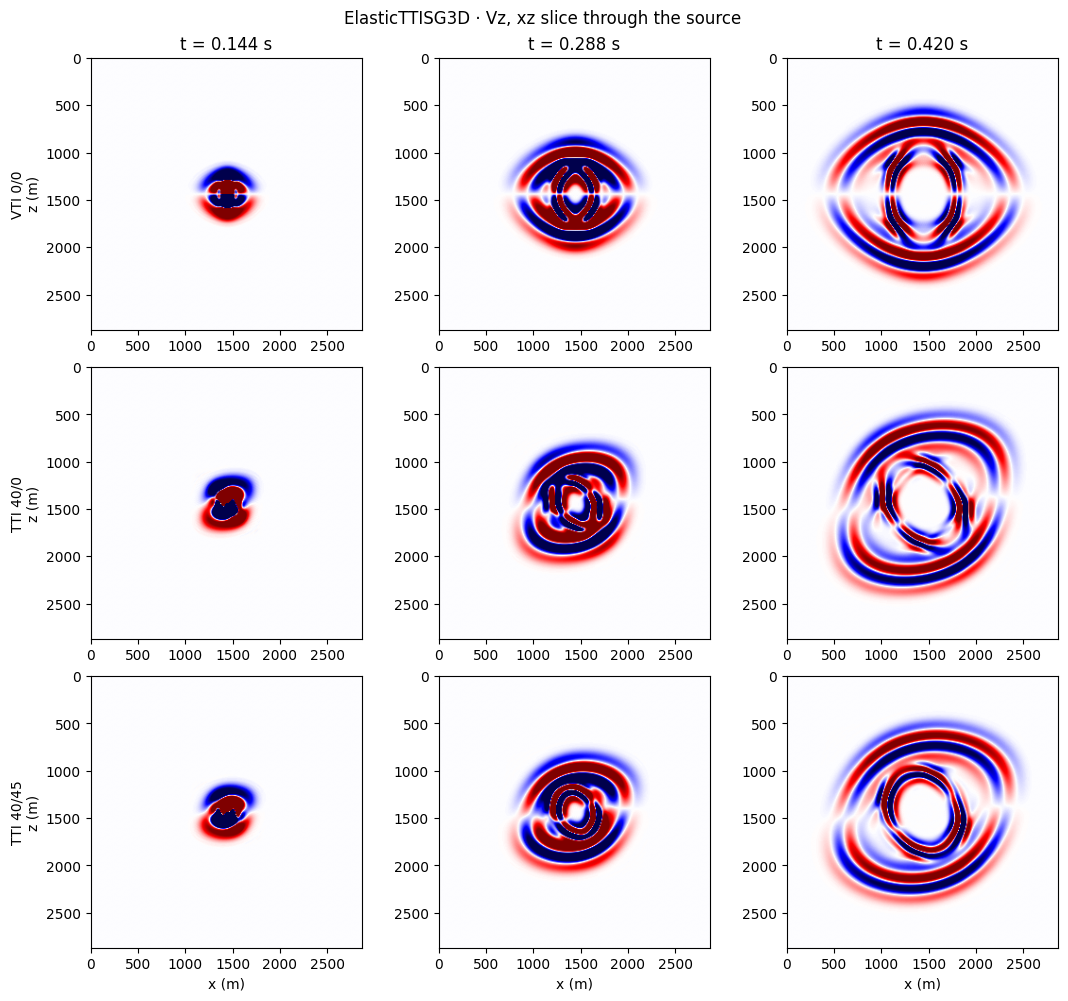

In [6]:
def lim(panels):
    a = np.concatenate([p.ravel() for p in panels])
    lo, hi = np.percentile(a, [2, 98])
    return float(lo), float(hi)

all_xz = [c[:, cy, :] for panels in cube.values() for c in panels]
lo, hi = lim(all_xz)
extent = (0, (shape[2] - 1) * dh, (shape[0] - 1) * dh, 0)

fig, axes = plt.subplots(len(ROTATION_CASES), len(snapshot_times),
                         figsize=(3.6 * len(snapshot_times), 3.3 * len(ROTATION_CASES)),
                         constrained_layout=True)
for r, (label, _, _) in enumerate(ROTATION_CASES):
    for c, (vol, ts) in enumerate(zip(cube[label], snapshot_times)):
        ax = axes[r, c]
        ax.imshow(vol[:, cy, :], cmap='seismic', vmin=lo, vmax=hi,
                  aspect='equal', extent=extent)
        if r == 0:
            ax.set_title(f't = {ts * dt:.3f} s')
        if c == 0:
            ax.set_ylabel(f'{label}\nz (m)')
        if r == len(ROTATION_CASES) - 1:
            ax.set_xlabel('x (m)')
fig.suptitle('ElasticTTISG3D · Vz, xz slice through the source')
plt.show()

## 6. The 3-D part: azimuth takes the wavefront out of plane

With φ = 45° the symmetry axis no longer lies in the x–z plane, so the
wavefront is no longer symmetric about it. Three orthogonal slices through the
source make that visible: the xy (map-view) slice shows the ellipse's long
axis rotated **in azimuth**, which is the piece a 2-D TTI solver cannot
represent at all.

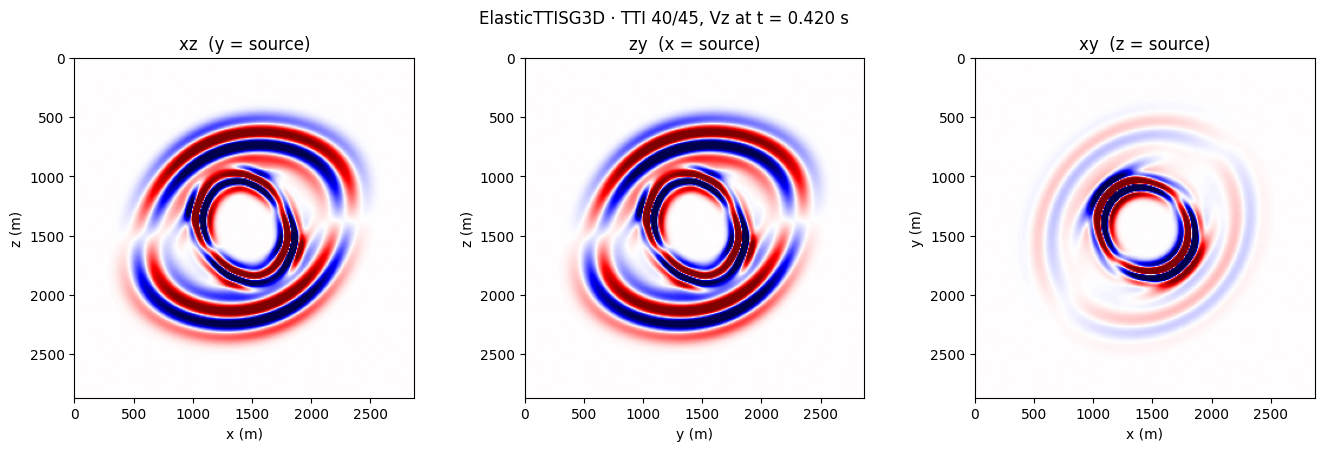

In [7]:
vol = cube['TTI 40/45'][-1]
slices = [
    (vol[:, cy, :], (0, (shape[2] - 1) * dh, (shape[0] - 1) * dh, 0), 'xz  (y = source)', 'x (m)', 'z (m)'),
    (vol[:, :, cx], (0, (shape[1] - 1) * dh, (shape[0] - 1) * dh, 0), 'zy  (x = source)', 'y (m)', 'z (m)'),
    (vol[cz],       (0, (shape[2] - 1) * dh, (shape[1] - 1) * dh, 0), 'xy  (z = source)', 'x (m)', 'y (m)'),
]
lo, hi = lim([s[0] for s in slices])
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), constrained_layout=True)
for ax, (panel, ext, title, xl, yl) in zip(axes, slices):
    ax.imshow(panel, cmap='seismic', vmin=lo, vmax=hi, aspect='equal', extent=ext)
    ax.set_title(title); ax.set_xlabel(xl); ax.set_ylabel(yl)
fig.suptitle(f'ElasticTTISG3D · TTI 40/45, Vz at t = {snapshot_times[-1] * dt:.3f} s')
plt.show()

## 7. Verification — the wavefront *is* the group-velocity surface

Everything above is a picture. Here is a check with a right answer.

In a homogeneous medium a point source radiates a front that, at time $t$, sits
at $|\mathbf{V}_g(\text{ray})|\,t$ along every ray, where $\mathbf{V}_g$ comes
from the **Christoffel equation**

$$\Gamma_{ik}(\mathbf{n}) = c_{ijkl}\,n_j n_l ,\qquad
  \Gamma\,\mathbf{g} = \rho V_\text{phase}^2\,\mathbf{g},\qquad
  V_{g,i} = \frac{c_{ijkl}\,n_l\,g_j g_k}{\rho\,V_\text{phase}} .$$

So overlaying that curve on the snapshot tests the whole chain — Bond rotation,
Voigt indexing, constitutive update, stencil — against theory rather than
against another implementation of the same code.

The reference below is built from the Thomsen parameters and solved in the
**crystal** frame, with only the rotation matrix crossing between frames. It
never touches the solver's stiffnesses, so an error in them shows up as a
mismatch.

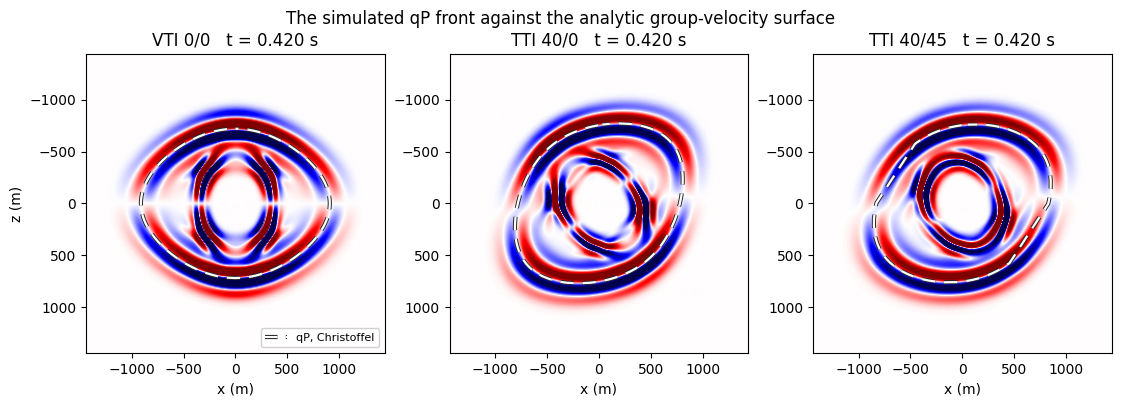

In [8]:
def qp_front(theta_deg, phi_deg, t, n_samp=400):
    """qP group-velocity surface cut by the y = 0 plane, in metres at time t."""
    C33 = rho_val * vp_val ** 2
    C44 = rho_val * vs_val ** 2
    C11 = C33 * (1 + 2 * epsilon_val)
    C66 = C44 * (1 + 2 * gamma_val)
    C13 = np.sqrt(2 * C33 * (C33 - C44) * delta_val + (C33 - C44) ** 2) - C44
    V = np.array([[C11, C11 - 2 * C66, C13, 0, 0, 0],
                  [C11 - 2 * C66, C11, C13, 0, 0, 0],
                  [C13, C13, C33, 0, 0, 0],
                  [0, 0, 0, C44, 0, 0], [0, 0, 0, 0, C44, 0], [0, 0, 0, 0, 0, C66]])
    voigt = np.array([[0, 5, 4], [5, 1, 3], [4, 3, 2]])
    c = V[voigt[:, :, None, None], voigt[None, None, :, :]]        # c_ijkl

    th, ph = np.deg2rad(theta_deg), np.deg2rad(phi_deg)
    ct, st, cp, sp = np.cos(th), np.sin(th), np.cos(ph), np.sin(ph)
    R = np.array([[cp * ct, -sp, cp * st],                          # lab <- crystal
                  [sp * ct, cp, sp * st],
                  [-st, 0.0, ct]])                                  # 3rd col = axis

    u = np.linspace(-1, 1, n_samp)
    az = np.linspace(0, 2 * np.pi, n_samp, endpoint=False)
    U, A = np.meshgrid(u, az, indexing='ij')
    s = np.sqrt(np.clip(1 - U ** 2, 0, None))
    n = np.stack([s * np.cos(A), s * np.sin(A), U], -1).reshape(-1, 3) @ R

    G = np.einsum('ijkl,pj,pl->pik', c, n, n)
    lam, vec = np.linalg.eigh(G)
    v, g = np.sqrt(lam[:, 2] / rho_val), vec[:, :, 2]               # qP branch
    vg = np.einsum('ijkl,pj,pk,pl->pi', c, g, g, n) / (rho_val * v[:, None]) @ R.T

    keep = np.abs(vg[:, 1]) / np.linalg.norm(vg, axis=1) < 3e-3     # the y = 0 cut
    vg = vg[keep]
    vg = vg[np.argsort(np.arctan2(vg[:, 0], vg[:, 2]))]
    return vg[:, 0] * t, vg[:, 2] * t


it_check = snapshot_times[-1]
travel = it_check * dt - delay                    # the front is |Vg| * travel
cx = shape[2] // 2

fig, axes = plt.subplots(1, len(ROTATION_CASES),
                         figsize=(3.7 * len(ROTATION_CASES), 3.9),
                         constrained_layout=True)
for ax, (label, th, ph) in zip(axes, ROTATION_CASES):
    vol = cube[label][-1][:, cy, :]
    ax.imshow(vol, cmap='seismic', vmin=lo, vmax=hi, aspect='equal',
              extent=(-cx * dh, cx * dh, cx * dh, -cx * dh))
    x, z = qp_front(th, ph, travel)
    ax.plot(x, z, 'w--', lw=1.6, dashes=(6, 4),
            path_effects=[pe.withStroke(linewidth=3.0, foreground='0.15')])
    ax.set_title(f'{label}   t = {it_check * dt:.3f} s')
    ax.set_xlabel('x (m)')
axes[0].set_ylabel('z (m)')
axes[0].plot([], [], 'w--', dashes=(6, 4),
             path_effects=[pe.withStroke(linewidth=3.0, foreground='0.15')],
             label='qP, Christoffel')
axes[0].legend(loc='lower right', fontsize=8, framealpha=0.9)
fig.suptitle('The simulated qP front against the analytic group-velocity surface')
plt.show()

The dashed curve lands on the front in all three panels, tilt and azimuth
included. Two things worth noticing:

* The curve is **not** a circle or an ellipse. `delta` controls the departure
  from elliptical, so a solver that quietly used an elliptical approximation
  would separate from it at the intermediate angles.
* At `TTI 40/45` the x–z plane is no longer a symmetry plane, so the curve is a
  genuine oblique cut through the 3-D surface — which is why it looks less
  anisotropic than `TTI 40/0` even though the medium is identical.

Quantitatively the picked front follows this curve to about **0.5 % in shape**
(against a 0.3 % floor measured the same way on an isotropic medium); the
residual few-percent common offset is grid dispersion, not anisotropy. The test
suite checks the rotation itself against an independent rank-4 rotation in
`test_bond_rotation_matches_independent_tensor_rotation`, and the full
end-to-end version of this comparison is `test_qp_wavefront_matches_christoffel`
(opt-in, `SWEEP_TEST_WAVEFRONT=1`).

## Notes

- **Backends.** `impl='eager'` here because it hands back the full field stack
  for snapshots. For gradients use `impl='c'`: forward, `full`, boundary
  saving and checkpointing are all implemented, and all eight parameters —
  velocities, density, the three Thomsen constants **and both angles** — match
  the eager autograd reference.
- **Grid.** The shear wave, not the P wave, sets `dh`: check
  `vs / (2.5 f0) / dh >= 5` for 4th order *before* trusting a snapshot. A run
  can be perfectly stable (CFL fine) and still be dominated by grid dispersion.
- **No free surface.** See the aside in §3.
